In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import subprocess
import json
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
def win_prob(A, B, scale=400):
    q = 10 ** ((A - B) / scale)
    k = -1.68 + 0.00136 * (A + B)/2
    k = max(0.1, min(k, 4))

    denom = q + 1 + k*np.sqrt(q)
    E_A = q / denom
    E_B = 1 / denom
    E_D = k * np.sqrt(q) / denom

    total = E_A + E_B + E_D
    E_A /= total
    E_B /= total
    E_D /= total

    return E_A, E_B, E_D


def update_elo(A, B, outcome, K, floor = 400):
    E_A, E_B, E_D = win_prob(A, B)
    E_A = E_A + 0.5 * E_D
    E_B = E_B + 0.5 * E_D
    
    A_new = A + K * (outcome - E_A)
    B_new = B + K * ((1 - outcome) - E_B)

    if A_new < floor:
        diff = floor - A_new
        A_new = floor
        B_new -= diff

    if B_new < floor:
        diff = floor - B_new
        B_new = floor
        A_new -= diff
    return A_new, B_new


def win_decider(p1, p2, p3):
    if not abs(p1 + p2 + p3 - 1) < 1e-8:
        raise ValueError("Probabilities must sum to 1.")
    r = random.uniform(0,1)
    if r < p1:
        return 1
    elif r < p1 + p2:
        return 0
    else:
        return 0.5


def k_factor(num_games):
    k  = 100*np.exp(-(np.log(3)/30)*num_games)+12
    return k

def simulate_stockfish_game(elo_A, elo_B, script_path="simulate_game.py"):
    """
    Call simulate_game.py with given ELOs and return the game result and positions.
    """
    cmd = ["python", script_path, str(elo_A), str(elo_B)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    # Parse JSON output
    return json.loads(result.stdout)

In [3]:
A = 600
B = 600

n = 100
a = np.zeros(n)
a[0] = A

b = np.zeros(n)
b[0] = B

for i in range(n-1):
    A, B = update_elo(A, B, outcome = 1, K = 16)
    a[i+1] = A
    b[i+1] = B

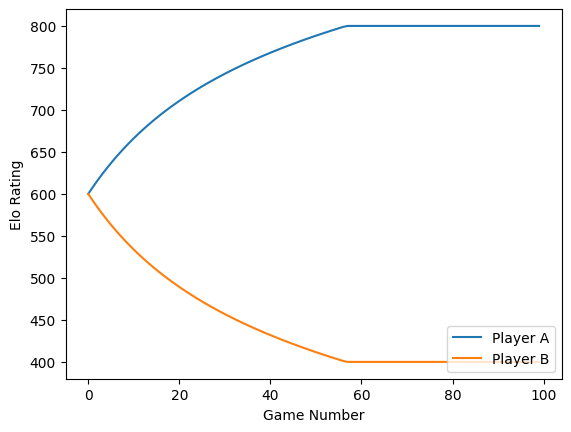

In [4]:
plt.plot(a, label="Player A")
plt.plot(b, label="Player B")
plt.xlabel("Game Number")
plt.ylabel("Elo Rating")
plt.legend(loc= "lower right")

In [5]:
A = 400
actual_A = 1000

n = 1000
B = np.random.uniform(400, 1000, size=n)
B = np.round(B, 0)

print(f"Initial rating of A: {A}")
print(f"Actual rating of A: {actual_A}\n")
# print(f"Initial ratings of B: {B}\n")

a = np.zeros(n+1)
a[0] = A

b = B.copy()
win_probs_A = np.zeros(n)
win_probs_B = np.zeros(n)
draw_probs = np.zeros(n)
winloss = np.zeros(n)

for i in range(n):
    win_probs_A[i], win_probs_B[i], draw_probs[i] = win_prob(actual_A, b[i])
    print(f"Win probability of A against B={b[i]}: {win_probs_A[i]:.3f}")
    
    winloss[i] = win_decider(win_probs_A[i], win_probs_B[i], draw_probs[i])
    print(f"Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): {winloss[i]}")
    
    a[i+1], b[i] = update_elo(a[i], b[i], outcome=winloss[i], K=k_factor(i+1))
    print(f"Updated ratings: A={a[i]:.1f}, B={b[i]:.1f}\n")

Initial rating of A: 400
Actual rating of A: 1000

Win probability of A against B=889.0: 0.625
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=400.0, B=787.8

Win probability of A against B=650.0: 0.855
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=501.2, B=577.3

Win probability of A against B=948.0: 0.547
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 0.5
Updated ratings: A=573.9, B=909.0

Win probability of A against B=691.0: 0.826
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 0.0
Updated ratings: A=613.0, B=729.8

Win probability of A against B=567.0: 0.900
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=574.1, B=520.3

Win probability of A against B=895.0: 0.617
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=620.8, B=819.6

Win probability of A against B=941.0: 0.557
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated rat

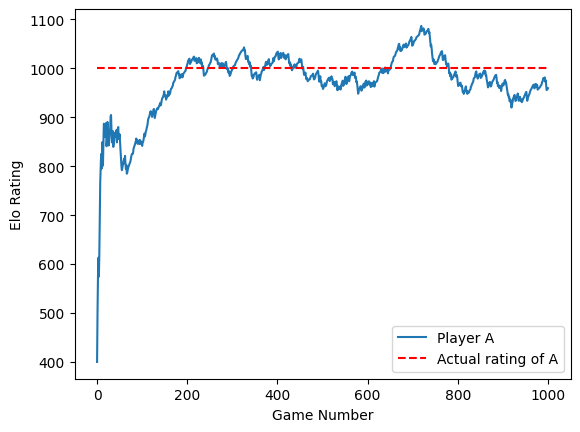

In [6]:
plt.plot(a, label="Player A")
plt.xlabel("Game Number")
plt.ylabel("Elo Rating")
plt.hlines(y=actual_A, xmin=0, xmax=len(a)-1, colors='r', linestyles='dashed', label="Actual rating of A")
plt.legend(loc= "lower right")
plt.show()

In [7]:
A = 600
actual_A = 2000

n = 500

print(f"Initial rating of A: {A}")
print(f"Actual rating of A: {actual_A}\n")

a = np.zeros(n+1)
a[0] = A

win_probs_A = np.zeros(n)
win_probs_B = np.zeros(n)
draw_probs = np.zeros(n)
winloss = np.zeros(n)
b = np.zeros(n)
b_wins = np.zeros(n)
b_losses = np.zeros(n)
draws = np.zeros(n)
actual_As = np.zeros(n)


for i in range(n):
    actual_As[i] = np.round(actual_A)
    b[i] =  max(a[i] + np.random.normal(0, int(0.05*a[i])), 400)
    b[i] = np.round(b[i], 0)

    win_probs_A[i], win_probs_B[i], draw_probs[i] = win_prob(actual_A, b[i])
    print(f"Win probability of A against B={b[i]}: {win_probs_A[i]:.3f}")
    
    winloss[i] = win_decider(win_probs_A[i], win_probs_B[i], draw_probs[i])
    print(f"Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): {winloss[i]}")
    
    a[i+1], b[i] = update_elo(a[i], b[i], outcome=winloss[i], K=k_factor(i+1))
    print(f"Updated ratings: A={a[i]:.1f}, B={b[i]:.1f}")
    print(f'Actual rating of A: {actual_A}\n')
    if winloss[i] == 0:
        b_wins[i] = b[i]
        b_losses[i] = None
        draws[i] = None
    elif winloss[i] == 1:
        b_losses[i] = b[i]
        b_wins[i] = None
        draws[i] = None
        # if actual_A < b[i]:
        #     actual_A += (b[i]/actual_A**2)*1e4
    else: 
        draws[i] = b[i]
        b_wins[i] = None
        b_losses[i] = None

Initial rating of A: 600
Actual rating of A: 2000

Win probability of A against B=561.0: 0.998
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=600.0, B=512.6
Actual rating of A: 2000

Win probability of A against B=645.0: 0.997
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=648.4, B=593.0
Actual rating of A: 2000

Win probability of A against B=733.0: 0.995
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=700.4, B=677.7
Actual rating of A: 2000

Win probability of A against B=757.0: 0.994
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=755.7, B=707.6
Actual rating of A: 2000

Win probability of A against B=774.0: 0.993
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=805.1, B=730.4
Actual rating of A: 2000

Win probability of A against B=850.0: 0.989
Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): 1.0
Updated ratings: A=848.7,

In [ ]:
# Example: simulate a game with ELOs from notebook
elo_A = 1500
elo_B = 600

game_data = simulate_stockfish_game(elo_A, elo_B)

print("Game terminated by:", game_data["termination"])
print("Winner:", game_data["winner_info"])
print("Numerical result:", game_data["numerical_result"])
print("Number of positions:", len(game_data["positions"]))

# Inspect the final board
import chess
final_board = chess.Board(game_data["positions"][-1])
print("\nFinal board position:")
print(final_board)

# from simulate_game import simulate_game

# # Now you can just call it:
# termination, winner_info, result, positions = simulate_game(elo_A=2000, elo_B=1600, time_limit=0.01)
# print(termination, winner_info, result)

In [ ]:
A = 600
actual_A = 2000

n = 500

print(f"Initial rating of A: {A}")
print(f"Actual rating of A: {actual_A}\n")

a = np.zeros(n+1)
a[0] = A

win_probs_A = np.zeros(n)
win_probs_B = np.zeros(n)
draw_probs = np.zeros(n)
winloss = np.zeros(n)
b = np.zeros(n)
b_wins = np.zeros(n)
b_losses = np.zeros(n)
draws = np.zeros(n)
actual_As = np.zeros(n)


for i in range(n):
    actual_As[i] = np.round(actual_A)
    b[i] =  max(a[i] + np.random.normal(0, int(0.05*a[i])), 400)
    b[i] = np.round(b[i], 0)

    # win_probs_A[i], win_probs_B[i], draw_probs[i] = win_prob(actual_A, b[i])
    # print(f"Win probability of A against B={b[i]}: {win_probs_A[i]:.3f}")
    
    # winloss[i] = win_decider(win_probs_A[i], win_probs_B[i], draw_probs[i])
    # print(f"Match outcome (1 if A wins, 0 if B wins, 0.5 if drawn): {winloss[i]}")

    
    
    a[i+1], b[i] = update_elo(a[i], b[i], outcome=winloss[i], K=k_factor(i+1))
    print(f"Updated ratings: A={a[i]:.1f}, B={b[i]:.1f}")
    print(f'Actual rating of A: {actual_A}\n')
    if winloss[i] == 0:
        b_wins[i] = b[i]
        b_losses[i] = None
        draws[i] = None
    elif winloss[i] == 1:
        b_losses[i] = b[i]
        b_wins[i] = None
        draws[i] = None
        # if actual_A < b[i]:
        #     actual_A += (b[i]/actual_A**2)*1e4
    else: 
        draws[i] = b[i]
        b_wins[i] = None
        b_losses[i] = None

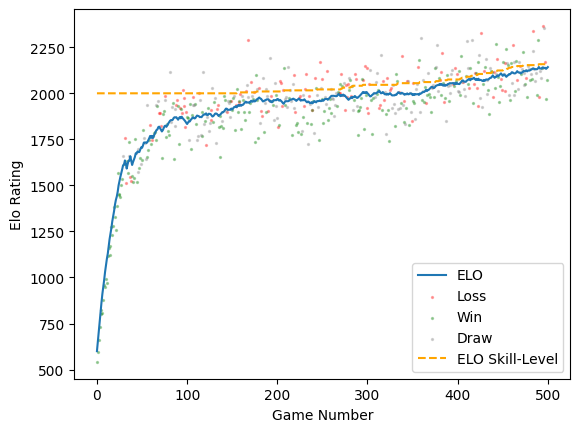

In [32]:
plt.plot(a, label="ELO")
plt.scatter(list(range(len(b_wins))),b_wins ,s=8, label="Loss", marker='.',color ='red', alpha = 0.3)
plt.scatter(list(range(len(b_losses))),b_losses,s=8 , label="Win", marker='.',color ='green', alpha = 0.3)
plt.scatter(list(range(len(draws))),draws,s=8 , label="Draw", marker='.',color ='grey', alpha = 0.3)
plt.xlabel("Game Number")
plt.ylabel("Elo Rating")
plt.plot(actual_As, label="ELO Skill-Level", color='orange', linestyle='dashed')
plt.legend(loc= "lower right")
plt.show()

Animation size has reached 21026029 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


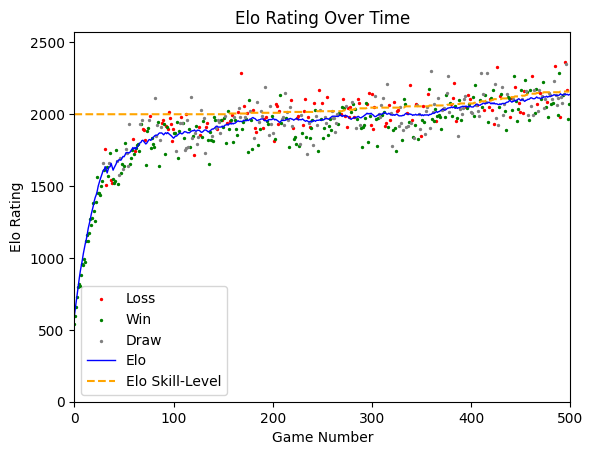

In [33]:
x1, y1 = list(range(len(b_wins))), b_wins
x2, y2 = list(range(len(b_losses))), b_losses
x3, y3 = list(range(len(draws))), draws
x_line = list(range(len(a)))
y_line = a
x_line2 = list(range(len(actual_As)))
y_line2 = actual_As


fig, ax = plt.subplots()
ax.set_title("Elo Rating Over Time")
ax.set_xlabel("Game Number")
ax.set_ylabel("Elo Rating")
ax.set_xlim(0, n)
ax.set_ylim(0, np.max(a)*1.2)

# Plot placeholders
sc1 = ax.scatter([], [], s=8, label="Loss", marker='.',color ='red', alpha = 1)
sc2 = ax.scatter([], [], s=8 , label="Win", marker='.',color ='green', alpha = 1)
sc3 = ax.scatter([], [],s=8 , label="Draw", marker='.',color ='grey', alpha = 1)
line, = ax.plot([], [], c='blue', lw=1, label='Elo')
line2, = ax.plot([], [], label="Elo Skill-Level", color='orange', linestyle='dashed')

ax.legend()

# ----------------------
# Initialization
# ----------------------
def init():
    sc1.set_offsets(np.empty((0, 2)))
    sc2.set_offsets(np.empty((0, 2)))
    sc3.set_offsets(np.empty((0, 2)))
    line.set_data([], [])
    line2.set_data([], [])
    return sc1, sc2, sc3, line, line2


# ----------------------
# Update function for animation
# ----------------------
def update(frame):
    # Update scatter (progressively add points)
    sc1.set_offsets(np.column_stack([x1[:frame], y1[:frame]]))
    sc2.set_offsets(np.column_stack([x2[:frame], y2[:frame]]))
    sc3.set_offsets(np.column_stack([x3[:frame], y3[:frame]]))
    
    # Update line
    line.set_data(x_line[:frame], y_line[:frame])
    line2.set_data(x_line2[:frame], y_line2[:frame])
    
    return sc1, sc2, sc3, line, line2

# ----------------------
# Animate
# ----------------------
frames = max(len(x1), len(x2), len(x3), len(x_line), len(x_line2))
ani = FuncAnimation(fig, update, frames=frames, init_func=init,
                    blit=True, interval=33, repeat=True)


HTML(ani.to_jshtml())
ani.save("elo_vs_games.gif", writer="pillow")

C:\Users\benmi\AppData\Local\Temp\ipykernel_7284\1894219897.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(cum_wins/cum_losses, label="Cumulative Wins of A")


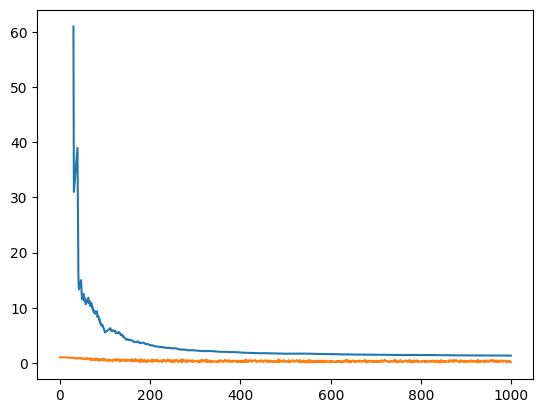

In [11]:
cum_wins = np.cumsum(winloss)
cum_losses = np.cumsum(1 - winloss)

plt.plot(cum_wins/cum_losses, label="Cumulative Wins of A")
plt.plot(win_probs_A, label="Cumulative Losses of A")